In [22]:
# ── CELL 1: Imports ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# ── CELL 2: Load Data ────────────────────────────────────────────
from google.colab import files
files.upload()
df = pd.read_csv('/content/tmdb_5000_movies.csv')

Saving tmdb_5000_movies.csv to tmdb_5000_movies (1).csv


In [16]:
# ── CELL 3: Quick Info ───────────────────────────────────────────
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(4803, 20)
budget                    int64
genres                   object
homepage                 object
id                        int64
keywords                 object
original_language        object
original_title           object
overview                 object
popularity              float64
production_companies     object
production_countries     object
release_date             object
revenue                   int64
runtime                 float64
spoken_languages         object
status                   object
tagline                  object
title                    object
vote_average            float64
vote_count                int64
dtype: object
budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date    

In [17]:
# ── CELL 4: Basic Stats ──────────────────────────────────────────
df.describe()


,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


In [18]:
# ── CELL 5: Cleaning ─────────────────────────────────────────────
# Zero budget/revenue means unknown
df["budget"]  = df["budget"].replace(0, np.nan)
df["revenue"] = df["revenue"].replace(0, np.nan)

# Fix dates
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["release_year"] = df["release_date"].dt.year

# Keep only released movies with enough votes
df = df[df["status"] == "Released"]
df = df[df["vote_count"] >= 10]

# New columns
df["profit"] = df["revenue"] - df["budget"]
df["roi"]    = df["profit"] / df["budget"]

print("Done. Shape:", df.shape)
df[["title", "vote_average", "budget", "revenue", "profit"]].head()


Done. Shape: (4390, 23)


,title,vote_average,budget,revenue,profit
0,Avatar,7.2,237000000.0,2.787965e+09,2.550965e+09
1,Pirates of the Caribbean: At World's End,6.9,300000000.0,9.610000e+08,6.610000e+08
2,Spectre,6.3,245000000.0,8.806746e+08,6.356746e+08
3,The Dark Knight Rises,7.6,250000000.0,1.084939e+09,8.349391e+08
4,John Carter,6.1,260000000.0,2.841391e+08,2.413910e+07


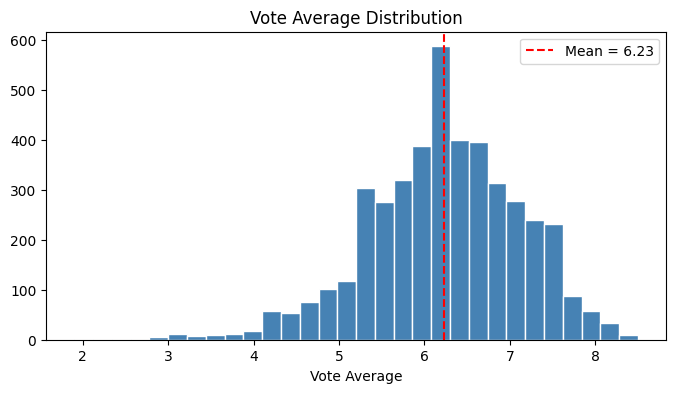

In [23]:
# ── CELL 6: Vote Average Distribution ───────────────────────────
plt.figure(figsize=(8, 4))
plt.hist(df["vote_average"], bins=30, color="steelblue", edgecolor="white")
plt.axvline(df["vote_average"].mean(), color="red", ls="--", label=f"Mean = {df['vote_average'].mean():.2f}")
plt.title("Vote Average Distribution")
plt.xlabel("Vote Average")
plt.legend()
plt.show()

/tmp/ipykernel_3319/2391444923.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_df, x="Count", y="Genre", palette="Blues_r")


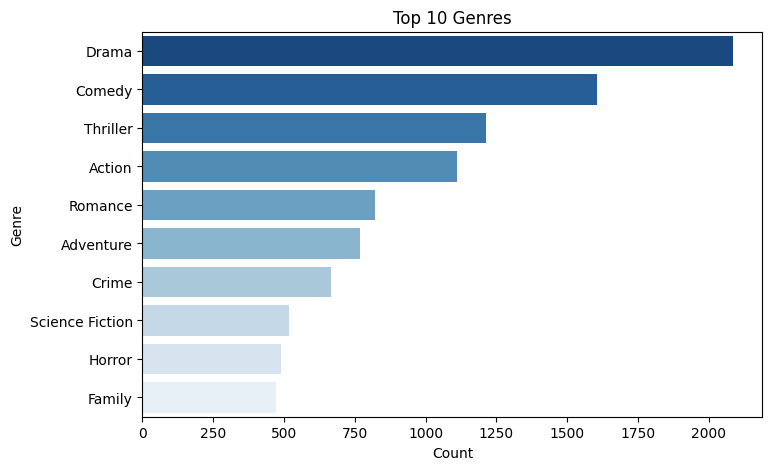

In [24]:
 #── CELL 7: Top 10 Genres ────────────────────────────────────────
import ast

def get_genres(val):
    try:
        return [d["name"] for d in ast.literal_eval(val)]
    except:
        return []

df["genres_list"] = df["genres"].apply(get_genres)

from collections import Counter
genre_counts = Counter(g for lst in df["genres_list"] for g in lst)
genre_df = pd.DataFrame(genre_counts.most_common(10), columns=["Genre", "Count"])

plt.figure(figsize=(8, 5))
sns.barplot(data=genre_df, x="Count", y="Genre", palette="Blues_r")
plt.title("Top 10 Genres")
plt.show()


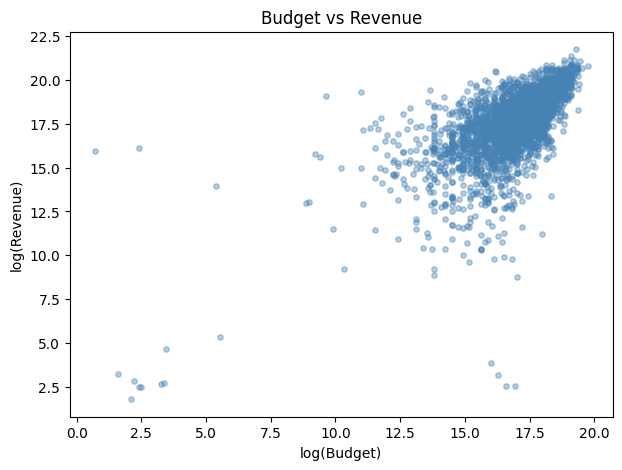

In [25]:
# ── CELL 8: Budget vs Revenue ────────────────────────────────────
fin = df.dropna(subset=["budget", "revenue"])

plt.figure(figsize=(7, 5))
plt.scatter(np.log1p(fin["budget"]), np.log1p(fin["revenue"]), alpha=0.4, s=15, color="steelblue")
plt.xlabel("log(Budget)")
plt.ylabel("log(Revenue)")
plt.title("Budget vs Revenue")
plt.show()


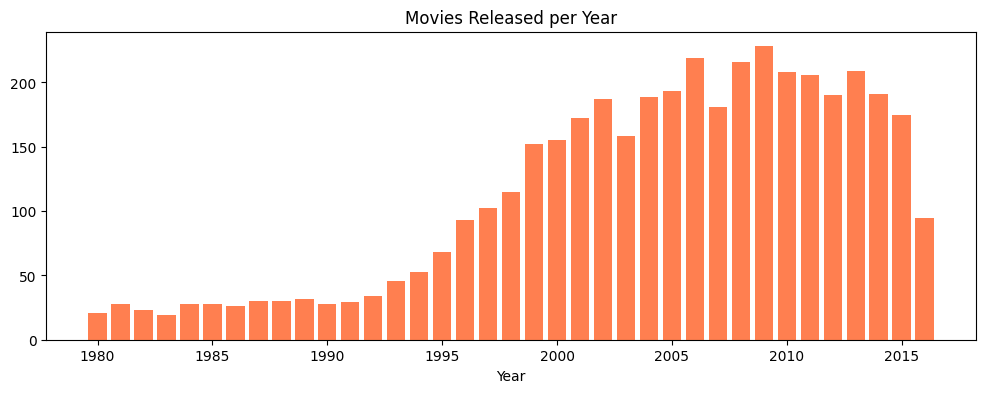

In [26]:
# ── CELL 9: Movies per Year ──────────────────────────────────────
year_counts = df[df["release_year"].between(1980, 2017)]["release_year"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
plt.bar(year_counts.index, year_counts.values, color="coral", width=0.8)
plt.title("Movies Released per Year")
plt.xlabel("Year")
plt.show()

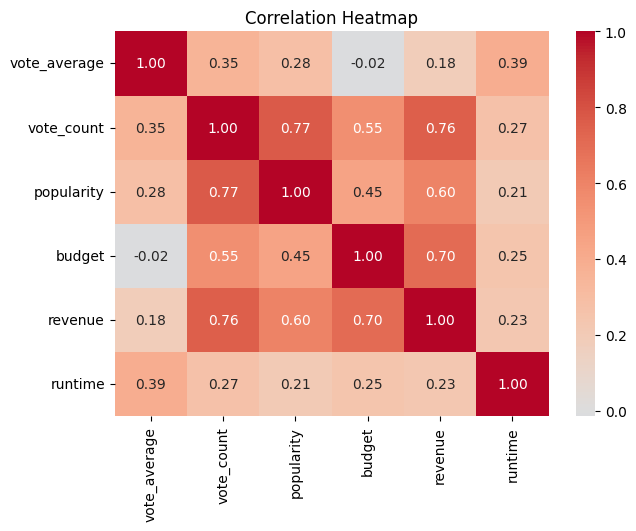

In [27]:
 #── CELL 10: Correlation Heatmap ─────────────────────────────────
cols = ["vote_average", "vote_count", "popularity", "budget", "revenue", "runtime"]
plt.figure(figsize=(7, 5))
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

/tmp/ipykernel_3319/4046528552.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x="vote_average", y="title", palette="viridis")


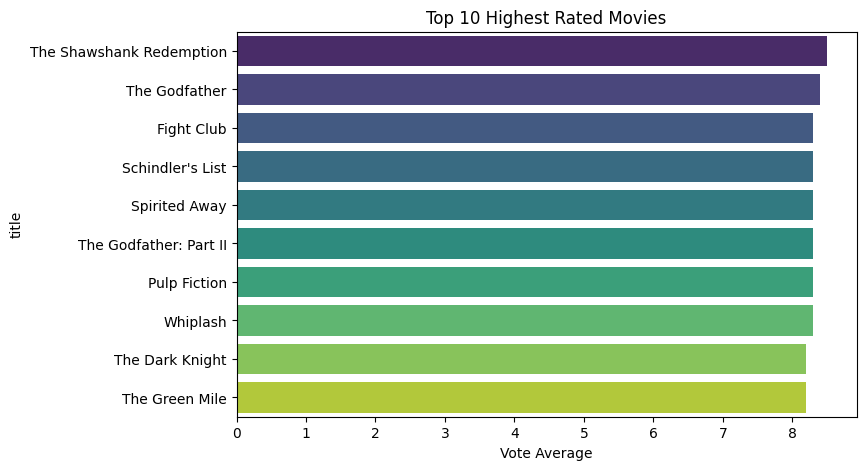

In [28]:
# ── CELL 11: Top 10 Highest Rated Movies ────────────────────────
top10 = df[df["vote_count"] >= 100].nlargest(10, "vote_average")[["title", "vote_average"]]

plt.figure(figsize=(8, 5))
sns.barplot(data=top10, x="vote_average", y="title", palette="viridis")
plt.title("Top 10 Highest Rated Movies")
plt.xlabel("Vote Average")
plt.show()
